In [1]:
# CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [2]:
# CELL 2: Import All Libraries
import os, random, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.19.0
GPU        : True


In [3]:
# CELL 3: Extract Dataset
# Update this path to match where FruitinAmazon.zip is in your Drive
ZIP_PATH    = '/content/drive/MyDrive/AI_Sem6/ Week 5 - Introduction to CNN/FruitinAmazon.zip'
EXTRACT_DIR = '/content/FruitinAmazon'

if not os.path.exists(EXTRACT_DIR):
    print('Extracting zip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')
    print('Done!')
else:
    print('Already extracted.')

TRAIN_DIR = os.path.join(EXTRACT_DIR, 'train')
TEST_DIR  = os.path.join(EXTRACT_DIR, 'test')
if not os.path.exists(TEST_DIR):
    TEST_DIR = None
    print('No test folder found - will use val split as test.')
else:
    print(f'Train: {TRAIN_DIR}')
    print(f'Test : {TEST_DIR}')

Extracting zip...
Done!
Train: /content/FruitinAmazon/train
Test : /content/FruitinAmazon/test


---
## Section 2.1 - Data Understanding and Visualisation

In [4]:
# CELL 4: Read Dataset Directory and Extract Class Names
class_names = sorted(os.listdir(TRAIN_DIR))

if not class_names:
    print('No class directories found in the train folder!')
else:
    print(f'Found {len(class_names)} classes: {class_names}')

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [5]:
# CELL 5: Check for Corrupted Images
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print('\nCorrupted Images Found:')
    for img in corrupted_images:
        print(img)
        os.remove(img)
else:
    print('\nNo corrupted images found.')


No corrupted images found.


In [6]:
# CELL 6: Count Class Balance
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print('\nClass Distribution:')
print('=' * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print('=' * 45)
for class_name, count in class_counts.items():
    print(f'{class_name:<25}{count:>15}')
print('=' * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


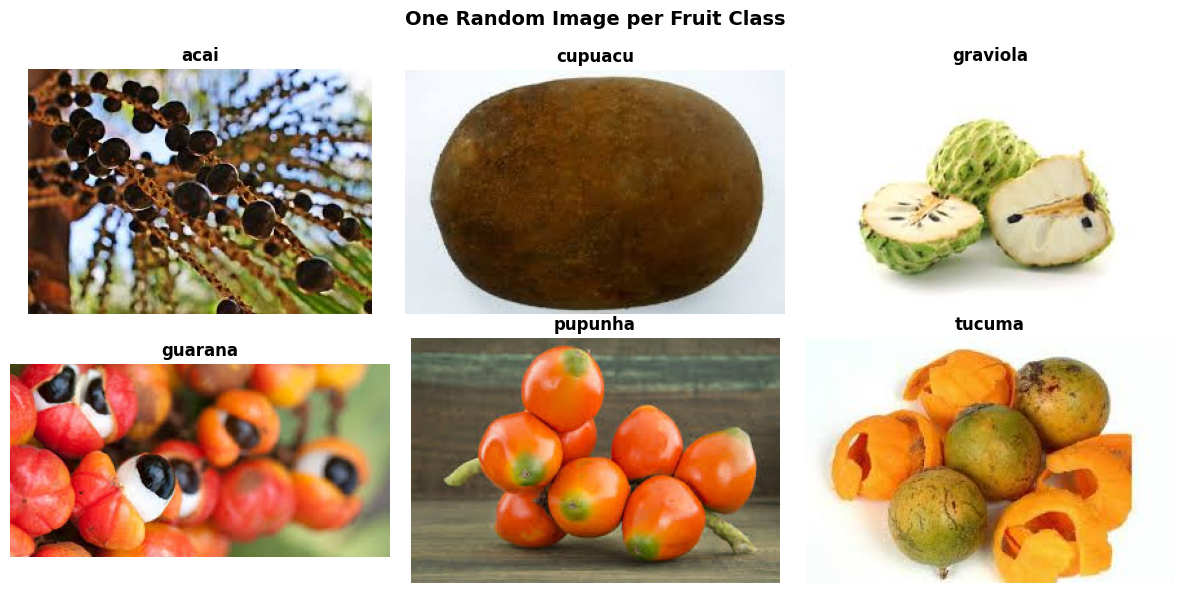

In [7]:
# CELL 7: Select Random Images and Visualise in Grid
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i], fontweight='bold')
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle('One Random Image per Fruit Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ws6_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2.2 - Data Augmentation and Preprocessing

In [8]:
# CELL 8: Dataset Parameters
IMG_HEIGHT  = 128
IMG_WIDTH   = 128
BATCH_SIZE  = 16
NUM_CLASSES = len(class_names)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
AUTOTUNE    = tf.data.AUTOTUNE

print(f'Image size  : {IMG_HEIGHT} x {IMG_WIDTH}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Num classes : {NUM_CLASSES}')

Image size  : 128 x 128
Batch size  : 16
Num classes : 6


In [9]:
# CELL 9: Load Train and Validation Datasets
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='both',
    seed=1337,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

# Check batch shape
for images, labels in train_ds.take(1):
    print('Images shape:', images.shape)
    print('Labels shape:', labels.shape)

# Load test set
if TEST_DIR:
    test_ds = keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=1337
    )
else:
    test_ds = val_ds

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
print('\nDatasets loaded and cached!')

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (16, 128, 128, 3)
Labels shape: (16,)
Found 30 files belonging to 6 classes.

Datasets loaded and cached!


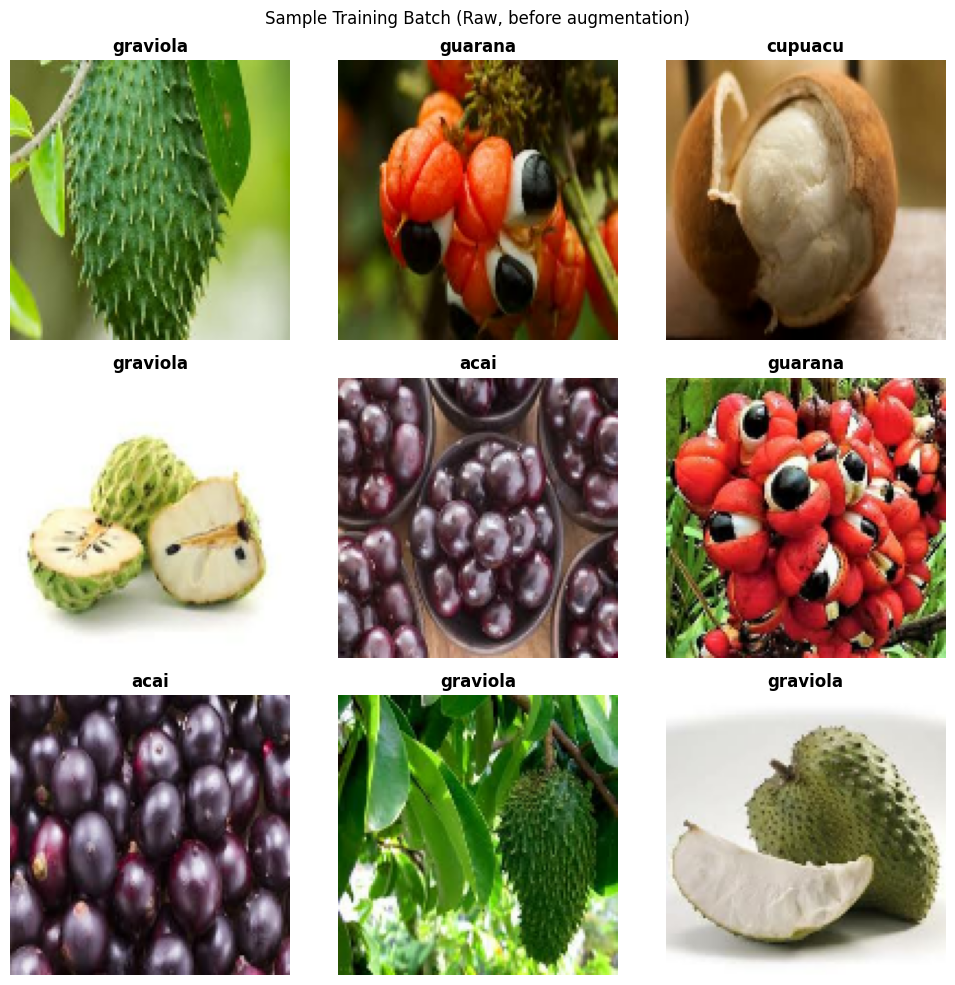

In [10]:
# CELL 10: Visualise a Raw Training Batch
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype('uint8'))
        plt.title(class_names[int(labels[i])], fontweight='bold')
        plt.axis('off')
plt.suptitle('Sample Training Batch (Raw, before augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# CELL 11: Define Data Augmentation Layers (New tf.keras.layers API - recommended)
# These will be embedded inside the model for GPU-accelerated augmentation
data_augmentation_layers = [
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print('Augmentation layers defined:')
for l in data_augmentation_layers:
    print(f'   {l.name}')

Augmentation layers defined:
   random_flip
   random_rotation
   random_zoom
   random_contrast


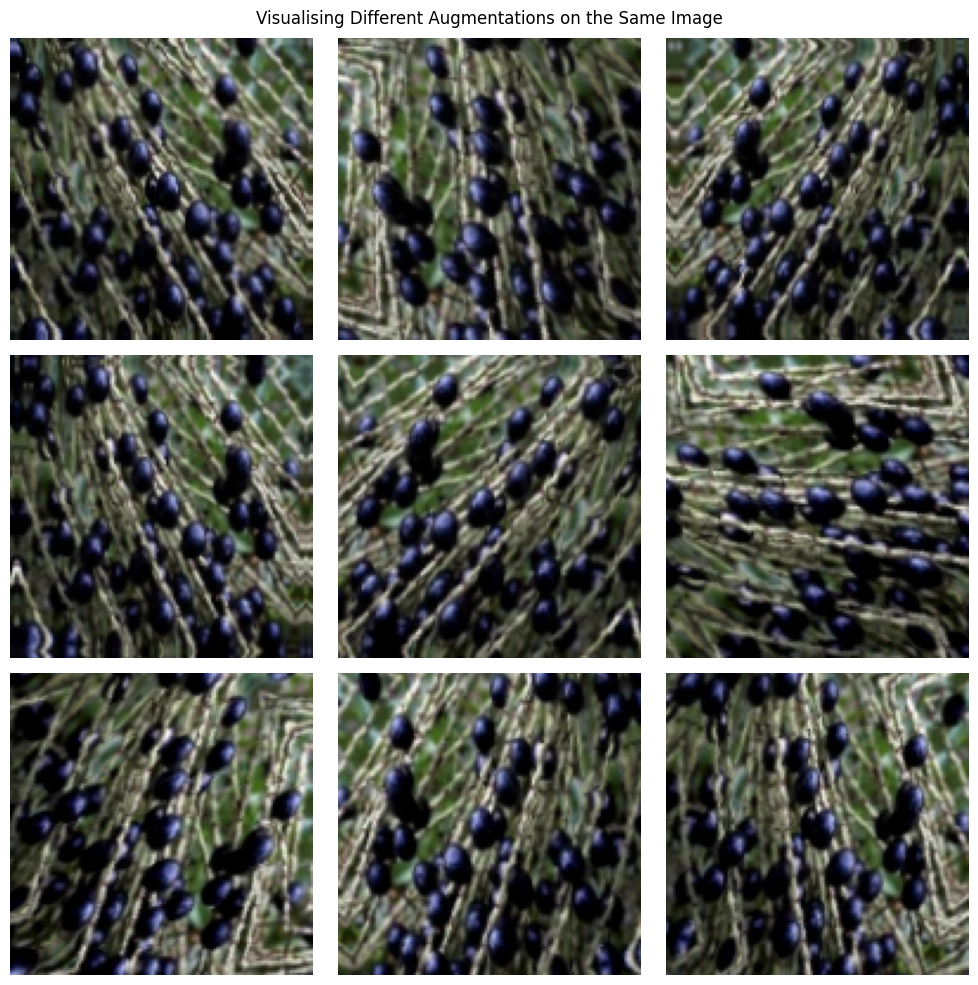

In [12]:
# CELL 12: Visualise Augmented Images
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype('uint8'))
        plt.axis('off')
plt.suptitle('Visualising Different Augmentations on the Same Image', fontsize=12)
plt.tight_layout()
plt.savefig('/content/ws6_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 1 - Improved CNN with Data Augmentation, Batch Normalisation and Dropout

Repeating all tasks from Worksheet 5 with a significantly improved architecture:
- **Data Augmentation** built inside the model (GPU accelerated)
- **Batch Normalisation** after every Conv layer (stabilises training)
- **Dropout** for regularisation (prevents overfitting)
- **Deeper architecture** (4 convolutional blocks)

In [13]:
# CELL 13: Build Improved CNN Model
# Architecture as specified in the worksheet sample:
#   4x Conv blocks (32 -> 64 -> 128 -> 256 filters)
#   Each block: Conv -> BN -> ReLU -> MaxPool -> Dropout(0.25)
#   FCN: Dense(512) -> Dense(256) with BN and Dropout(0.5)

def build_improved_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Data Augmentation + Rescaling inside model (recommended - GPU accelerated)
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.1)(x)
    x = layers.Rescaling(1.0 / 255)(x)

    # Conv Block 1: 32 filters
    x = Conv2D(32, (3, 3), padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Conv Block 2: 64 filters
    x = Conv2D(64, (3, 3), padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Conv Block 3: 128 filters
    x = Conv2D(128, (3, 3), padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Conv Block 4: 256 filters
    x = Conv2D(256, (3, 3), padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Fully Connected Network
    x = Flatten()(x)

    x = Dense(512, activation=None)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation=None)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    # Output Layer
    outputs = Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ImprovedCNN_WS6')
    return model

model_t1 = build_improved_cnn(INPUT_SHAPE, NUM_CLASSES)
model_t1.summary()

Model: "ImprovedCNN_WS6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,915,398 (34.01 MB)

 Trainable params: 8,912,902 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [14]:
# CELL 14: Compile the Model
model_t1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled with Adam optimiser.')

Model compiled with Adam optimiser.


In [15]:
# CELL 15: Define Callbacks
CKPT_T1 = '/content/best_ws6_task1.keras'

callbacks_t1 = [
    ModelCheckpoint(CKPT_T1, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1)
]
print('Callbacks ready - ModelCheckpoint + EarlyStopping (patience=25)')

Callbacks ready - ModelCheckpoint + EarlyStopping (patience=25)


In [16]:
# CELL 16: Train Task 1 Model
# Note: Augmentation and Rescaling are INSIDE the model
# So raw pixel values [0-255] are passed directly from the dataset

print('Training improved CNN | max 250 epochs | EarlyStopping patience=25\n')

history_t1 = model_t1.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=callbacks_t1,
    verbose=1
)
print('\nTraining complete!')

Training improved CNN | max 250 epochs | EarlyStopping patience=25

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.0788 - loss: 2.5827
Epoch 1: val_accuracy improved from None to 0.05556, saving model to /content/best_ws6_task1.keras

Epoch 1: finished saving model to /content/best_ws6_task1.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 379ms/step - accuracy: 0.0972 - loss: 2.4585 - val_accuracy: 0.0556 - val_loss: 1.8039
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4087 - loss: 1.4290
Epoch 2: val_accuracy improved from 0.05556 to 0.27778, saving model to /content/best_ws6_task1.keras

Epoch 2: finished saving model to /content/best_ws6_task1.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.4028 - loss: 1.4570 - val_accuracy: 0.2778 - val_loss: 1.7267
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5368 - loss: 1.4158
Epoch 3: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4861 - loss: 1

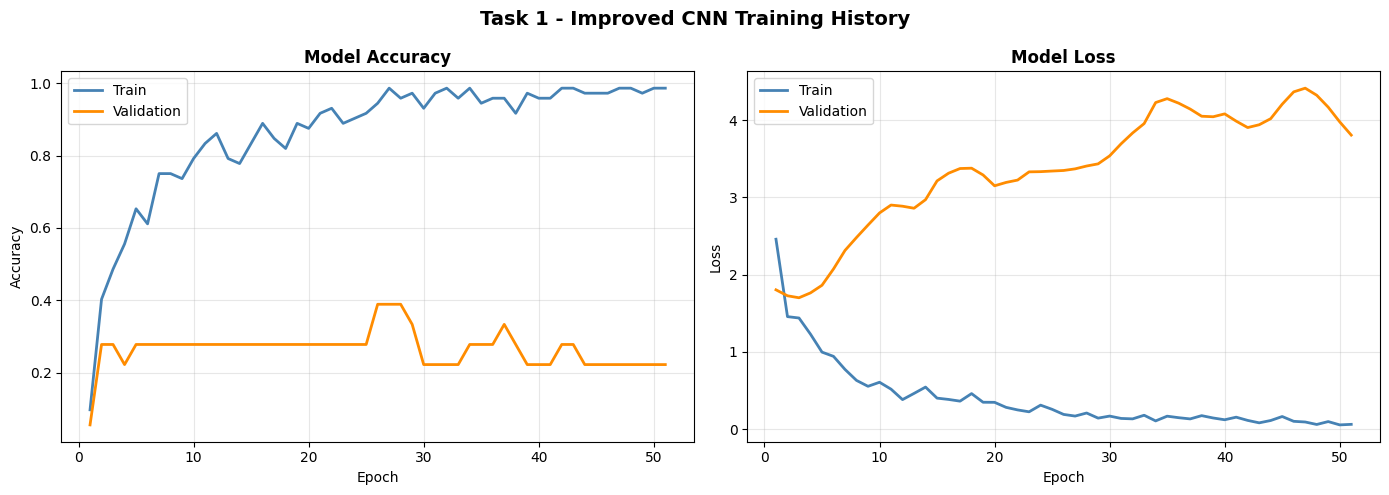

In [17]:
# CELL 17: Plot Task 1 Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history_t1.history['accuracy']) + 1)

ax1.plot(ep, history_t1.history['accuracy'],     label='Train',      color='steelblue',  lw=2)
ax1.plot(ep, history_t1.history['val_accuracy'], label='Validation', color='darkorange', lw=2)
ax1.set_title('Model Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history_t1.history['loss'],     label='Train',      color='steelblue',  lw=2)
ax2.plot(ep, history_t1.history['val_loss'], label='Validation', color='darkorange', lw=2)
ax2.set_title('Model Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Task 1 - Improved CNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ws6_task1_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# CELL 18: Evaluate Task 1 Model on Test Set
print('Evaluating on test set...')
t1_loss, t1_acc = model_t1.evaluate(test_ds, verbose=1)
print('\n' + '='*45)
print(f'  Task 1 Test Loss     : {t1_loss:.4f}')
print(f'  Task 1 Test Accuracy : {t1_acc:.4f}  ({t1_acc*100:.2f}%)')
print('='*45)

Evaluating on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.2333 - loss: 4.1781

  Task 1 Test Loss     : 4.1781
  Task 1 Test Accuracy : 0.2333  (23.33%)


In [19]:
# CELL 19: Save Task 1 Model
model_t1.save('/content/ws6_task1_final.keras')
print('Task 1 model saved to /content/ws6_task1_final.keras')

Task 1 model saved to /content/ws6_task1_final.keras


In [20]:
# CELL 20: Load and Re-evaluate Saved Model
loaded_t1 = keras.models.load_model('/content/ws6_task1_final.keras')
print('Model loaded from disk.')
loaded_loss, loaded_acc = loaded_t1.evaluate(test_ds, verbose=1)
print(f'\nLoaded Model Test Accuracy : {loaded_acc:.4f} ({loaded_acc*100:.2f}%)')
print('Results match - model saved and loaded correctly.')

Model loaded from disk.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2333 - loss: 4.1781 

Loaded Model Test Accuracy : 0.2333 (23.33%)
Results match - model saved and loaded correctly.


In [21]:
# CELL 21: Task 1 - Predictions and Classification Report
y_true_t1, y_pred_t1 = [], []
for images, labels in test_ds:
    preds = loaded_t1.predict(images, verbose=0)
    y_pred_t1.extend(np.argmax(preds, axis=1))
    y_true_t1.extend(labels.numpy())

print('Task 1 - Classification Report\n')
print('='*60)
print(classification_report(y_true_t1, y_pred_t1, target_names=class_names))
print('='*60)

Task 1 - Classification Report

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.18      0.40      0.25         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.26      1.00      0.42         5

    accuracy                           0.23        30
   macro avg       0.07      0.23      0.11        30
weighted avg       0.07      0.23      0.11        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


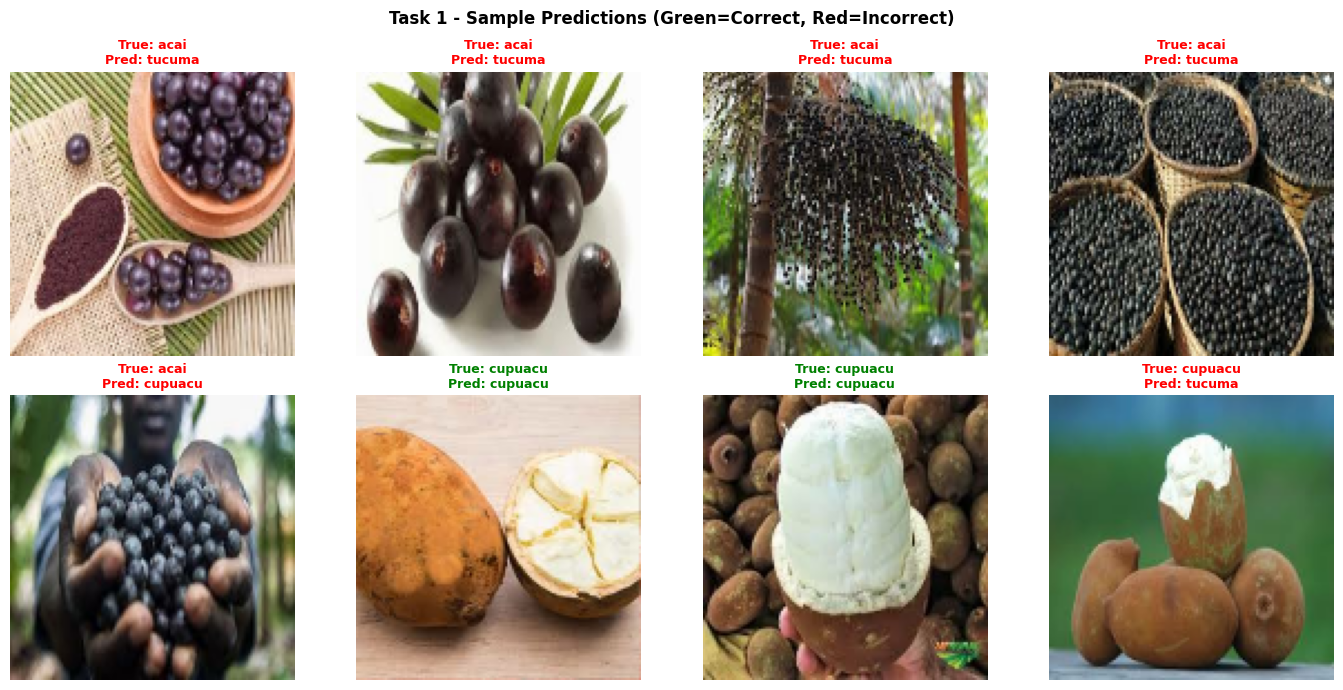

In [22]:
# CELL 22: Task 1 - Visualise Sample Predictions
sample_imgs, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_t1.predict(sample_imgs, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    if i < len(sample_imgs):
        ax.imshow(np.array(sample_imgs[i]).astype('uint8'))
        true_l = class_names[sample_labels[i]]
        pred_l = class_names[sample_preds[i]]
        color  = 'green' if true_l == pred_l else 'red'
        ax.set_title(f'True: {true_l}\nPred: {pred_l}', color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Task 1 - Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ws6_task1_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2 - Transfer Learning with VGG16

Using a pre-trained VGG16 (ImageNet weights) with frozen layers.
Only the custom classification head is trained on the fruit dataset.

Steps:
1. Load VGG16 without top layer
2. Freeze base model layers
3. Add custom classification head
4. Build final model
5. Compile and fit

In [23]:
# CELL 23: Reload Datasets at VGG16 Native Size (224x224)
VGG_SIZE = 224

train_ds_vgg, val_ds_vgg = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset='both',
    seed=1337,
    image_size=(VGG_SIZE, VGG_SIZE),
    batch_size=BATCH_SIZE,
)

if TEST_DIR:
    test_ds_vgg = keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=(VGG_SIZE, VGG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=1337
    )
else:
    test_ds_vgg = val_ds_vgg

# Normalise pixel values to [0, 1]
rescale = layers.Rescaling(1.0 / 255)
train_ds_vgg = train_ds_vgg.map(lambda x, y: (rescale(x), y)).cache().prefetch(AUTOTUNE)
val_ds_vgg   = val_ds_vgg.map(lambda x, y: (rescale(x), y)).cache().prefetch(AUTOTUNE)
test_ds_vgg  = test_ds_vgg.map(lambda x, y: (rescale(x), y)).cache().prefetch(AUTOTUNE)

print(f'VGG16 datasets ready at {VGG_SIZE}x{VGG_SIZE}')

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
VGG16 datasets ready at 224x224


In [24]:
# CELL 24: Step 1 - Load VGG16 Pre-trained Model (without top layer)
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',        # Pre-trained on ImageNet
    include_top=False,         # Exclude final dense classification layers
    input_shape=(VGG_SIZE, VGG_SIZE, 3)
)
print('VGG16 base model loaded with ImageNet weights.')
print(f'Total layers in VGG16 base : {len(base_model.layers)}')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base model loaded with ImageNet weights.
Total layers in VGG16 base : 19


In [25]:
# CELL 25: Step 2 - Freeze All Base Model Layers
for layer in base_model.layers:
    layer.trainable = False

frozen_count = sum(1 for l in base_model.layers if not l.trainable)
print(f'Frozen {frozen_count} layers.')
print('VGG16 weights will NOT be updated during training.')

Frozen 19 layers.
VGG16 weights will NOT be updated during training.


In [26]:
# CELL 26: Step 3 - Add Custom Classification Head
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

x = base_model.output
x = GlobalAveragePooling2D()(x)          # Reduce spatial dims to a single vector
x = Dense(1024, activation='relu')(x)    # Fully connected layer with 1024 neurons
x = Dropout(0.5)(x)                      # Regularisation
x = Dense(NUM_CLASSES, activation='softmax')(x)  # Output layer for 6 fruit classes

print('Custom classification head added.')

Custom classification head added.


In [27]:
# CELL 27: Step 4 - Create the Final Model
model_vgg = Model(inputs=base_model.input, outputs=x, name='VGG16_TransferLearning')

# Show trainable vs frozen param count
trainable_params   = sum(np.prod(v.shape) for v in model_vgg.trainable_variables)
frozen_params      = sum(np.prod(v.shape) for v in model_vgg.non_trainable_variables)

print('Final model built.')
print(f'  Trainable params    : {trainable_params:,}  (custom head only)')
print(f'  Non-trainable params: {frozen_params:,}  (frozen VGG16)')
model_vgg.summary()

Final model built.
  Trainable params    : 531,462  (custom head only)
  Non-trainable params: 14,714,690  (frozen VGG16)


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
# CELL 28: Step 5 - Compile the VGG16 Model
from tensorflow.keras.optimizers import Adam

model_vgg.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('VGG16 model compiled with Adam optimiser.')

VGG16 model compiled with Adam optimiser.


In [29]:
# CELL 29: Train VGG16 Transfer Learning Model
CKPT_VGG = '/content/best_ws6_vgg16.keras'

callbacks_vgg = [
    ModelCheckpoint(CKPT_VGG, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1)
]

print('Training VGG16 transfer learning model | max 250 epochs\n')
history_vgg = model_vgg.fit(
    train_ds_vgg,
    epochs=250,
    validation_data=val_ds_vgg,
    callbacks=callbacks_vgg,
    verbose=1
)
print('\nVGG16 training complete!')

Training VGG16 transfer learning model | max 250 epochs

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0785 - loss: 2.0674  
Epoch 1: val_accuracy improved from None to 0.05556, saving model to /content/best_ws6_vgg16.keras

Epoch 1: finished saving model to /content/best_ws6_vgg16.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.1111 - loss: 1.9764 - val_accuracy: 0.0556 - val_loss: 1.8973
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4066 - loss: 1.4987
Epoch 2: val_accuracy improved from 0.05556 to 0.22222, saving model to /content/best_ws6_vgg16.keras

Epoch 2: finished saving model to /content/best_ws6_vgg16.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.4444 - loss: 1.4409 - val_accuracy: 0.2222 - val_loss: 1.8945
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5500 - loss: 1.3384
Epoch 3: val_accuracy improved from 0.22222 to 0.27778, saving model to /content/best_ws6_vgg16.keras

Epoch 3: finished saving mode

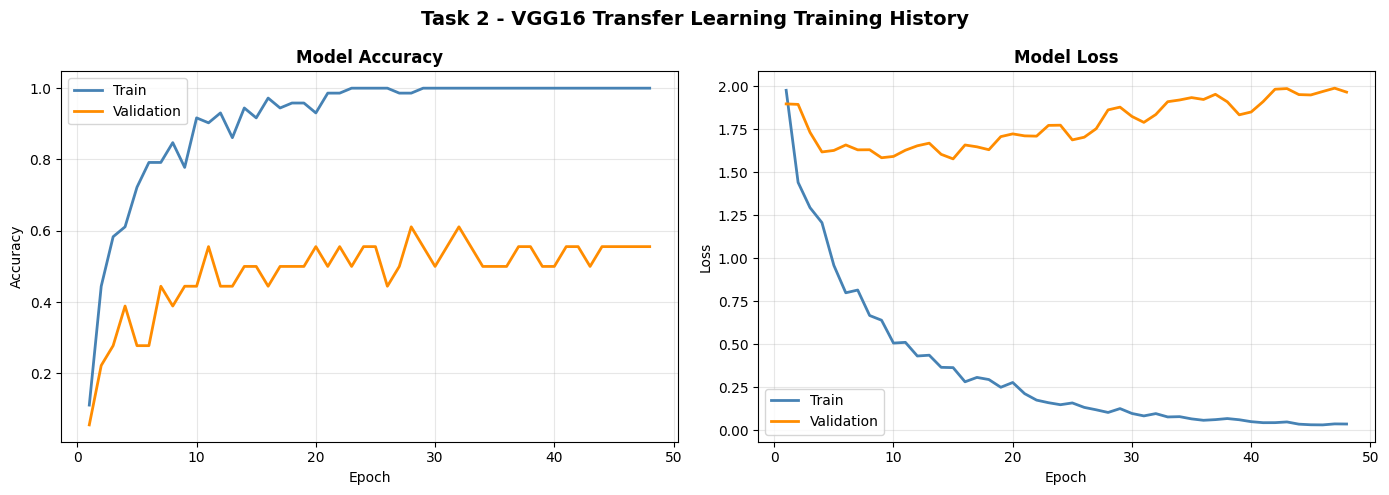

In [30]:
# CELL 30: Plot VGG16 Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history_vgg.history['accuracy']) + 1)

ax1.plot(ep, history_vgg.history['accuracy'],     label='Train',      color='steelblue',  lw=2)
ax1.plot(ep, history_vgg.history['val_accuracy'], label='Validation', color='darkorange', lw=2)
ax1.set_title('Model Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history_vgg.history['loss'],     label='Train',      color='steelblue',  lw=2)
ax2.plot(ep, history_vgg.history['val_loss'], label='Validation', color='darkorange', lw=2)
ax2.set_title('Model Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Task 2 - VGG16 Transfer Learning Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ws6_task2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# CELL 31: Evaluate VGG16 Model on Test Set
print('Evaluating VGG16 on test set...')
vgg_loss, vgg_acc = model_vgg.evaluate(test_ds_vgg, verbose=1)
print('\n' + '='*45)
print(f'  VGG16 Test Loss     : {vgg_loss:.4f}')
print(f'  VGG16 Test Accuracy : {vgg_acc:.4f}  ({vgg_acc*100:.2f}%)')
print('='*45)

Evaluating VGG16 on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5667 - loss: 1.4676

  VGG16 Test Loss     : 1.4676
  VGG16 Test Accuracy : 0.5667  (56.67%)


In [32]:
# CELL 32: Save VGG16 Model
model_vgg.save('/content/ws6_vgg16_final.keras')
print('VGG16 model saved to /content/ws6_vgg16_final.keras')

VGG16 model saved to /content/ws6_vgg16_final.keras


In [33]:
# CELL 33: VGG16 - Inference Output and Classification Report
y_true_vgg, y_pred_vgg = [], []
for images, labels in test_ds_vgg:
    preds = model_vgg.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

print('Task 2 - VGG16 Classification Report\n')
print('='*60)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))
print('='*60)

Task 2 - VGG16 Classification Report

              precision    recall  f1-score   support

        acai       0.50      0.40      0.44         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.75      0.60      0.67         5
     guarana       0.62      1.00      0.77         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.43      0.60      0.50         5

    accuracy                           0.57        30
   macro avg       0.63      0.57      0.54        30
weighted avg       0.63      0.57      0.54        30



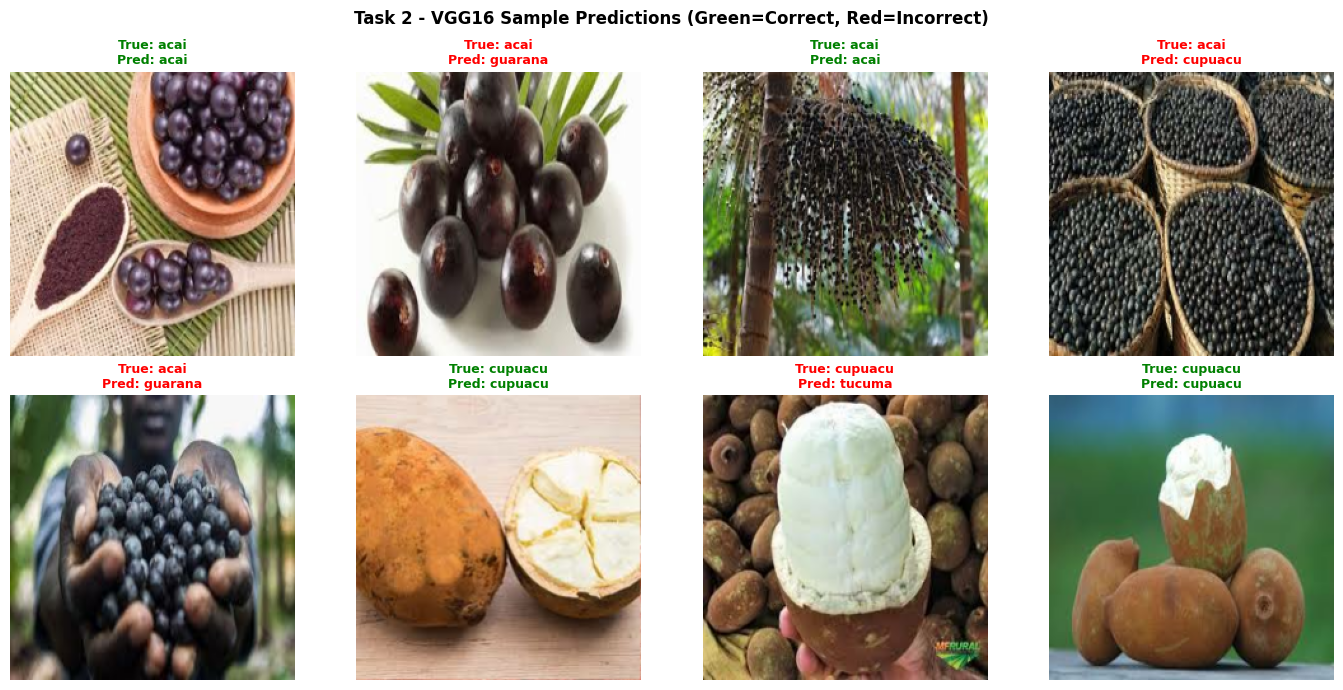

In [34]:
# CELL 34: VGG16 - Visualise Sample Predictions
sample_imgs_vgg, sample_labels_vgg = next(iter(test_ds_vgg))
sample_preds_vgg = np.argmax(model_vgg.predict(sample_imgs_vgg, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    if i < len(sample_imgs_vgg):
        ax.imshow(np.array(sample_imgs_vgg[i]))
        true_l = class_names[sample_labels_vgg[i]]
        pred_l = class_names[sample_preds_vgg[i]]
        color  = 'green' if true_l == pred_l else 'red'
        ax.set_title(f'True: {true_l}\nPred: {pred_l}', color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Task 2 - VGG16 Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ws6_task2_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Final Comparison - Worksheet 5 vs Task 1 vs Task 2

In [35]:
# CELL 35: Model Comparison Summary
print('=' * 60)
print(f"{'Model':<35} {'Test Accuracy':>15}")
print('=' * 60)
print(f"{'Worksheet 5  (Basic CNN)':<35} {'60.00%':>15}")
print(f"{'Task 1       (CNN + BN + Dropout + Aug)':<35} {f'{t1_acc*100:.2f}%':>15}")
print(f"{'Task 2       (VGG16 Transfer Learning)':<35} {f'{vgg_acc*100:.2f}%':>15}")
print('=' * 60)

print('\nAnalysis:')
if vgg_acc > t1_acc and vgg_acc > 0.60:
    print('  Transfer Learning (VGG16) outperforms both models.')
    print('  Pre-trained ImageNet features are very effective for small datasets.')
elif t1_acc > 0.60:
    print('  Improved CNN (BN + Dropout + Augmentation) outperforms the basic CNN.')
    print('  Regularisation techniques helped reduce overfitting.')
print('\n  With only 15 training images per class, transfer learning is')
print('  the most practical approach for this small dataset.')

Model                                 Test Accuracy
Worksheet 5  (Basic CNN)                     60.00%
Task 1       (CNN + BN + Dropout + Aug)          23.33%
Task 2       (VGG16 Transfer Learning)          56.67%

Analysis:

  With only 15 training images per class, transfer learning is
  the most practical approach for this small dataset.
